In [7]:
import pandas as pd
df = pd.read_excel('Cooking Oil Sales Data.xlsx')

df.head()

,Month,Product,Demand,Inventory_On_Hand,Orders_Placed,Lead_Time_Days,Stock_Received,Stockout,Inventory Turnover,Fill Rate,KPI,Unnamed: 11
0,2024-01-01,Cooking Oil (1L bottle),1800,650,2000,6,1950,0,2.769231,1.083333,Total Demand,49660.000000
1,2024-02-01,Cooking Oil (1L bottle),1780,620,1950,5,1920,0,2.870968,1.078652,Avg Inventory Turnover,3.938279
2,2024-03-01,Cooking Oil (1L bottle),1850,600,2000,6,1980,0,3.083333,1.070270,Stock-out Rate,0.250000
3,2024-04-01,Cooking Oil (1L bottle),1900,580,2050,7,2000,0,3.275862,1.052632,Avg Lead Time,6.583333
4,2024-05-01,Cooking Oil (1L bottle),1960,540,2100,6,2050,0,3.629630,1.045918,NaN,NaN


**KPI Calculations**

In [16]:
import numpy as np

# Calculate Total Demand
total_demand = df['Demand'].sum()

# Calculate Average Inventory Turnover
avg_turnover = df['Inventory Turnover'].mean()

# Calculate Stockout Rate (assuming 1 for stockout, 0 for no stockout)
stockout_rate = df['Stockout'].sum() / len(df) # len(df) gives the number of months/rows

# Calculate Average Lead Time
avg_lead_time = df['Lead_Time_Days'].mean()

print(f"Total Demand: {total_demand:.0f}")
print(f"Average Inventory Turnover: {avg_turnover:.2f}")
print(f"Stockout Rate: {stockout_rate:.2%}")
print(f"Average Lead Time: {avg_lead_time:.2f} days")

Total Demand: 49660
Average Inventory Turnover: 3.94
Stockout Rate: 25.00%
Average Lead Time: 6.58 days


**Demand Trend Line**

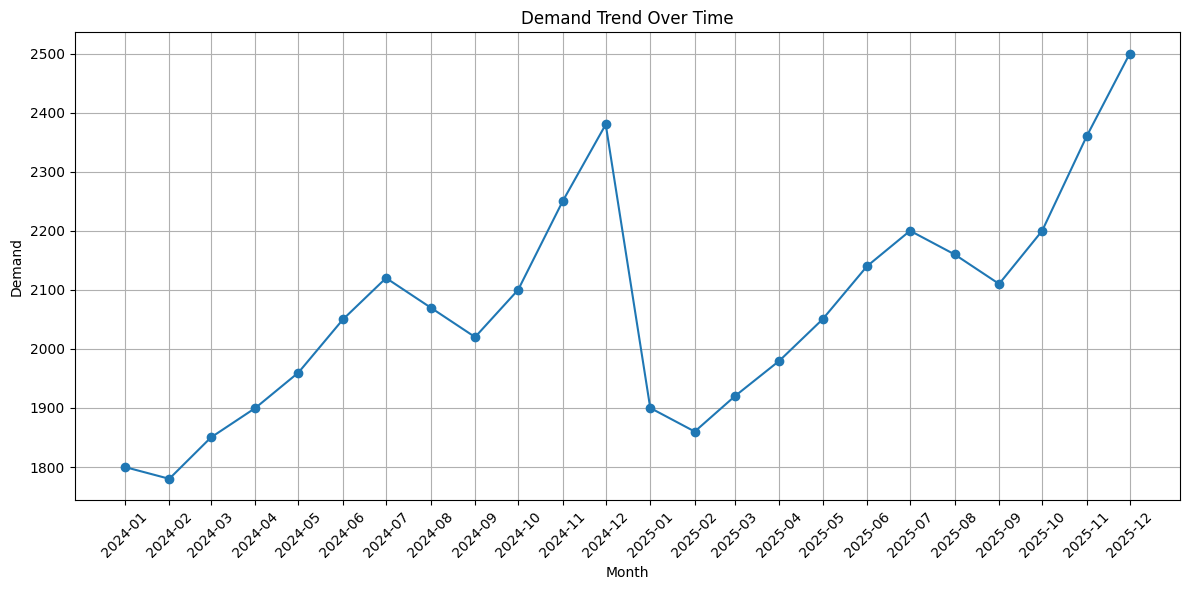

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['Month'], df['Demand'], marker='o', linestyle='-')
plt.title('Demand Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Demand')
plt.grid(True)
# Set x-axis ticks to display all unique months
plt.xticks(df['Month'], df['Month'].dt.strftime('%Y-%m'), rotation=45)
plt.tight_layout()
plt.show()

**Inventory Turnover Efficiency**

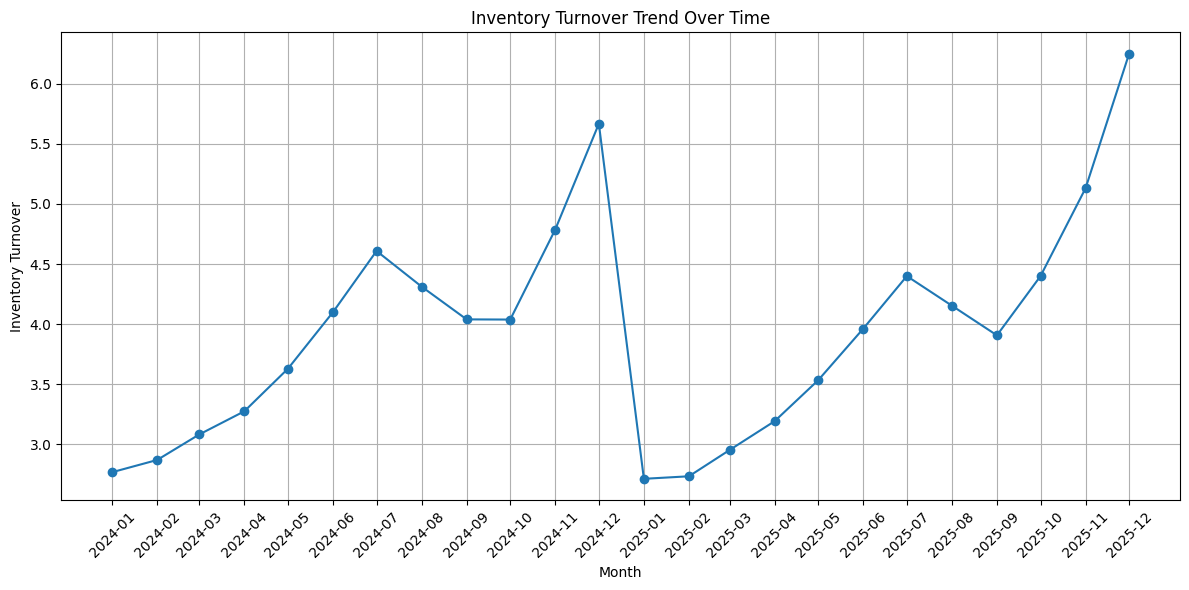

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(df['Month'], df['Inventory Turnover'], marker='o', linestyle='-')
plt.title('Inventory Turnover Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Inventory Turnover')
plt.grid(True)
plt.xticks(df['Month'], df['Month'].dt.strftime('%Y-%m'), rotation=45)
plt.tight_layout()
plt.show()

**Lead Time Trend**

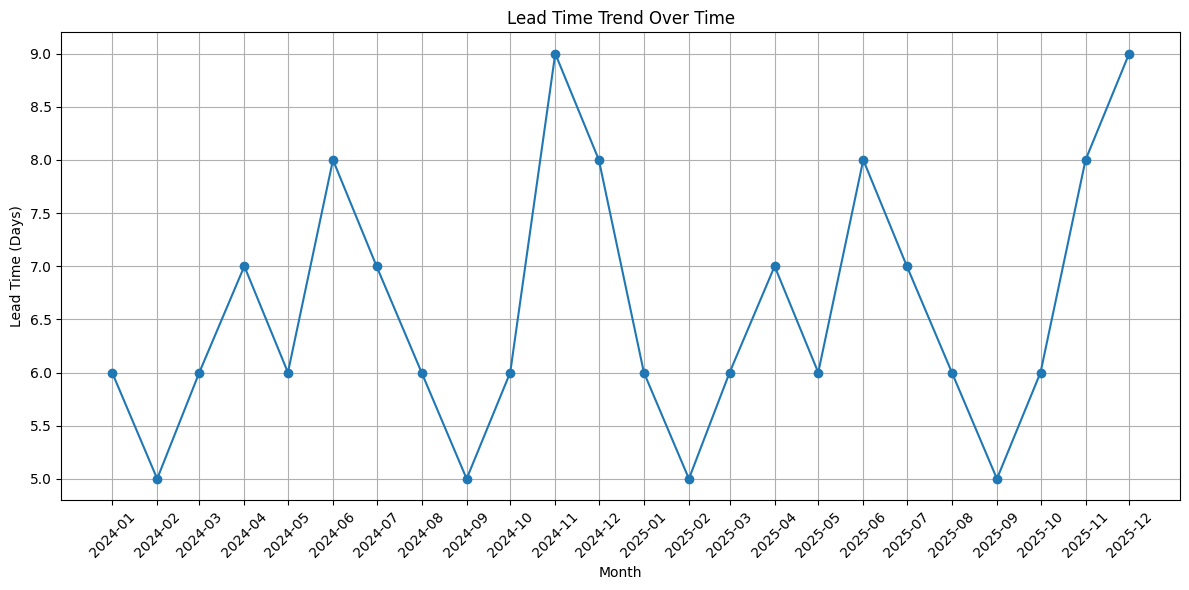

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(df['Month'], df['Lead_Time_Days'], marker='o', linestyle='-')
plt.title('Lead Time Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Lead Time (Days)')
plt.grid(True)
plt.xticks(df['Month'], df['Month'].dt.strftime('%Y-%m'), rotation=45)
plt.tight_layout()
plt.show()

**Stockout Occurrences**

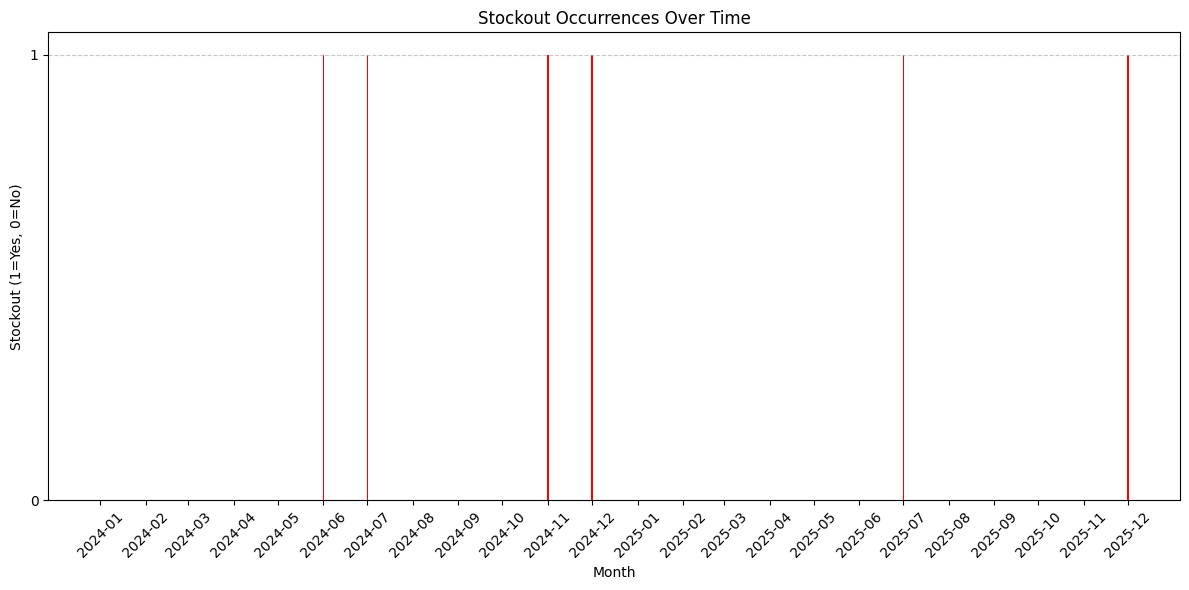

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(df['Month'], df['Stockout'], color='Red')
plt.title('Stockout Occurrences Over Time')
plt.xlabel('Month')
plt.ylabel('Stockout (1=Yes, 0=No)')
plt.yticks([0, 1]) # Set y-axis to only show 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(df['Month'], df['Month'].dt.strftime('%Y-%m'), rotation=45)
plt.tight_layout()
plt.show()

**High Stockout Months**

In [17]:
# Group by month and sum the 'Stockout' column
stockout_by_month = df.groupby('Month')['Stockout'].sum().reset_index()

# Filter for months where stockout occurred (sum > 0)
high_stockout_months = stockout_by_month[stockout_by_month['Stockout'] > 0]

print("Months with Stockout Occurrences:")
if not high_stockout_months.empty:
    for _, row in high_stockout_months.iterrows():
        print(f"- {row['Month'].strftime('%Y-%m')}")
else:
    print("No stockout occurrences detected.")

Months with Stockout Occurrences:
- 2024-06
- 2024-07
- 2024-11
- 2024-12
- 2025-07
- 2025-12


**Worst Inventory Efficiency Months**

In [18]:
# Sort by 'Inventory Turnover' in ascending order to find the lowest values
worst_inventory_months = df.sort_values(by='Inventory Turnover', ascending=True).head()

print("Months with the worst Inventory Efficiency (lowest turnover):")
if not worst_inventory_months.empty:
    for _, row in worst_inventory_months.iterrows():
        print(f"- {row['Month'].strftime('%Y-%m')} (Inventory Turnover: {row['Inventory Turnover']:.2f})")
else:
    print("No inventory data available to determine efficiency.")

Months with the worst Inventory Efficiency (lowest turnover):
- 2025-01 (Inventory Turnover: 2.71)
- 2025-02 (Inventory Turnover: 2.74)
- 2024-01 (Inventory Turnover: 2.77)
- 2024-02 (Inventory Turnover: 2.87)
- 2025-03 (Inventory Turnover: 2.95)


**Lead Time Problem Spikes**

In [19]:
# Sort by 'Lead_Time_Days' in descending order to find the highest values
lead_time_spikes = df.sort_values(by='Lead_Time_Days', ascending=False).head()

print("Months with Lead Time Problem Spikes (highest lead time):")
if not lead_time_spikes.empty:
    for _, row in lead_time_spikes.iterrows():
        print(f"- {row['Month'].strftime('%Y-%m')} (Lead Time: {row['Lead_Time_Days']:.0f} days)")
else:
    print("No lead time data available.")

Months with Lead Time Problem Spikes (highest lead time):
- 2025-12 (Lead Time: 9 days)
- 2024-11 (Lead Time: 9 days)
- 2024-06 (Lead Time: 8 days)
- 2025-06 (Lead Time: 8 days)
- 2024-12 (Lead Time: 8 days)


**Simple Insight: Conditions During Stockouts**

In [21]:
stockout_months_df = df[df['Stockout'] == 1]
no_stockout_months_df = df[df['Stockout'] == 0]

avg_stockout_metrics = stockout_months_df[['Demand', 'Inventory_On_Hand', 'Lead_Time_Days', 'Inventory Turnover']].mean()
avg_no_stockout_metrics = no_stockout_months_df[['Demand', 'Inventory_On_Hand', 'Lead_Time_Days', 'Inventory Turnover']].mean()

print("Average metrics during months with stockouts:")
print(avg_stockout_metrics)
print("\nAverage metrics during months without stockouts:")
print(avg_no_stockout_metrics)

print("\n--- Insight ---")
print("Months with stockouts tend to have:")
if avg_stockout_metrics['Demand'] > avg_no_stockout_metrics['Demand']:
    print(f"- Higher Average Demand (Stockout: {avg_stockout_metrics['Demand']:.0f} vs No Stockout: {avg_no_stockout_metrics['Demand']:.0f})")
if avg_stockout_metrics['Inventory_On_Hand'] < avg_no_stockout_metrics['Inventory_On_Hand']:
    print(f"- Lower Average Inventory On Hand (Stockout: {avg_stockout_metrics['Inventory_On_Hand']:.0f} vs No Stockout: {avg_no_stockout_metrics['Inventory_On_Hand']:.0f})")
if avg_stockout_metrics['Lead_Time_Days'] > avg_no_stockout_metrics['Lead_Time_Days']:
    print(f"- Longer Average Lead Time (Stockout: {avg_stockout_metrics['Lead_Time_Days']:.1f} days vs No Stockout: {avg_no_stockout_metrics['Lead_Time_Days']:.1f} days)")
if avg_stockout_metrics['Inventory Turnover'] < avg_no_stockout_metrics['Inventory Turnover']:
     print(f"- Lower Average Inventory Turnover (Stockout: {avg_stockout_metrics['Inventory Turnover']:.2f} vs No Stockout: {avg_no_stockout_metrics['Inventory Turnover']:.2f})")
else:
     print(f"- Higher Average Inventory Turnover (Stockout: {avg_stockout_metrics['Inventory Turnover']:.2f} vs No Stockout: {avg_no_stockout_metrics['Inventory Turnover']:.2f})")

print("\nThis suggests stockouts are often associated with a combination of higher demand, lower inventory levels, and longer lead times.")

Average metrics during months with stockouts:
Demand                2250.000000
Inventory_On_Hand      458.333333
Lead_Time_Days           8.000000
Inventory Turnover       4.968766
dtype: float64

Average metrics during months without stockouts:
Demand                2008.888889
Inventory_On_Hand      571.111111
Lead_Time_Days           6.111111
Inventory Turnover       3.594783
dtype: float64

--- Insight ---
Months with stockouts tend to have:
- Higher Average Demand (Stockout: 2250 vs No Stockout: 2009)
- Lower Average Inventory On Hand (Stockout: 458 vs No Stockout: 571)
- Longer Average Lead Time (Stockout: 8.0 days vs No Stockout: 6.1 days)
- Higher Average Inventory Turnover (Stockout: 4.97 vs No Stockout: 3.59)

This suggests stockouts are often associated with a combination of higher demand, lower inventory levels, and longer lead times.


**Insight:**
Months with stockouts tend to have:
- Higher Average Demand (Stockout: 2250 vs No Stockout: 2009)
- Lower Average Inventory On Hand (Stockout: 458 vs No Stockout: 571)
- Longer Average Lead Time (Stockout: 8.0 days vs No Stockout: 6.1 days)
- Higher Average Inventory Turnover (Stockout: 4.97 vs No Stockout: 3.59)

This suggests stockouts are often associated with a combination of higher demand, lower inventory levels, and longer lead times.